# Black-Scholes Delta Hedging: Discrete Replication and Gamma Error Analysis

---

## Abstract

This notebook provides a rigorous simulation-based study of discrete delta hedging under the Black-Scholes-Merton (BSM) framework. We implement and analyse a self-financing delta hedging strategy applied to European call and put options, where the hedge portfolio is rebalanced at discrete, equally spaced intervals rather than continuously.

The central research question is: **how does the discrete hedging error behave across paths, and how well does the gamma-based second-order approximation explain it?**

We simulate geometric Brownian motion price paths, compute option sensitivities analytically, and run a discrete hedging backtest over 1,000 paths. We then compare the realised hedge profit and loss (P&L) to the theoretical gamma error prediction, study the effect of rebalancing frequency, and visualise the structure of a single hedge path in detail.

**Key findings:**
- Under daily rebalancing, the gamma error closely tracks the realised hedge P&L.
- Increasing the rebalancing interval inflates the standard deviation of the hedging error.
- The mean hedging error remains near zero in the absence of transaction costs, consistent with theory.

---

## 1. Theoretical Background

### 1.1 The Black-Scholes-Merton Framework

Under the BSM model, the risk-neutral dynamics of the underlying asset $S_t$ are governed by:

$$
dS_t = (r - q)\, S_t\, dt + \sigma\, S_t\, dW_t
$$

where:
- $r$ is the continuously compounded risk-free rate,
- $q$ is the continuous dividend yield,
- $\sigma$ is the constant volatility,
- $W_t$ is a standard Brownian motion under the risk-neutral measure $\mathbb{Q}$.

The continuous dividend yield $q$ accounts for cash flows paid by the underlying at a constant rate. It enters the pricing formula through a discount factor $e^{-qT}$ applied to the stock, reducing the effective forward price from $S e^{rT}$ to $S e^{(r-q)T}$.

### 1.2 The $d_1$ and $d_2$ Quantities

The BSM formula relies on two standardised distance-to-strike measures:

$$
d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

$N(d_2)$ is the risk-neutral probability that the option expires in-the-money. $N(d_1)$ determines the sensitivity of the option price to the underlying.

### 1.3 European Option Pricing Formulas

**European Call:**
$$
C = S\, e^{-qT}\, N(d_1) - K\, e^{-rT}\, N(d_2)
$$

**European Put:**
$$
P = K\, e^{-rT}\, N(-d_2) - S\, e^{-qT}\, N(-d_1)
$$

Both satisfy put-call parity: $C - P = S\,e^{-qT} - K\,e^{-rT}$.

### 1.4 Option Greeks

The key sensitivities used in this project are:

| Greek | Definition | Call | Put |
|-------|-----------|------|-----|
| **Delta** $\Delta$ | $\partial V / \partial S$ | $e^{-qT}N(d_1)$ | $-e^{-qT}N(-d_1)$ |
| **Gamma** $\Gamma$ | $\partial^2 V / \partial S^2$ | $\frac{e^{-qT}N'(d_1)}{S\sigma\sqrt{T}}$ | same |
| **Vega** $\mathcal{V}$ | $\partial V / \partial \sigma$ | $S\,e^{-qT}N'(d_1)\sqrt{T}$ | same |
| **Theta** $\Theta$ | $\partial V / \partial t$ | see code | see code |

Note that $\Gamma$ and $\mathcal{V}$ are identical for calls and puts — a direct consequence of put-call parity.

### 1.5 Self-Financing Delta Hedging

A **self-financing** portfolio requires no external capital injections after inception. A delta hedge of a short call position consists of:
- Long $\Delta_t$ shares of the underlying,
- A cash account $B_t$ that finances the share position.

The portfolio value is $\Pi_t = \Delta_t S_t + B_t$. Under continuous rebalancing and the BSM assumptions, $\Pi_t = V_t$ almost surely — the hedge is perfect.

### 1.6 Discrete Rebalancing and the Origin of Hedging Error

In practice, the portfolio is rebalanced only at discrete times $\{t_0, t_1, \dots, t_n\}$ with $dt = T/n$. Between rebalancing dates, the delta is held constant at its value from the previous date. The hedging error over one interval $[t_{i-1}, t_i]$ arises because the option price moves non-linearly in $S$ while the hedge is only linear (delta).

A second-order Taylor expansion of $V(S + dS)$ around $S$ gives:

$$
dV \approx \Delta\, dS + \frac{1}{2}\Gamma\, (dS)^2
$$

The delta component is exactly offset by the hedge position. The residual is the **gamma P&L** term:

$$
\text{Hedge P\&L} \approx \frac{1}{2}\Gamma\, (dS)^2
$$

However, under risk-neutral pricing the theta of the option exactly offsets the expected gamma P&L. The **unexpected** component (the part not priced in) is:

$$
\epsilon_\Gamma = -\frac{1}{2}\Gamma \left[(dS)^2 - \sigma^2 S^2 dt\right]
$$

This is the gamma error term implemented in `hedging.py`. The quantity $(dS)^2 - \sigma^2 S^2 dt$ measures the deviation of the realised squared return from its risk-neutral expectation. When the realised variance exceeds the implied variance priced into the option, the short-gamma hedger loses; when it falls below, the hedger gains.

Summing across all rebalancing intervals gives the total gamma error approximation for the full path:

$$
\Gamma\text{-error} = -\sum_{i} \frac{1}{2}\Gamma_i \left[(\Delta S_i)^2 - \sigma^2 S_i^2 \Delta t_i\right]
$$

where each $\Gamma_i$ is evaluated at the start of the $i$-th interval.

---

## 2. Project Structure and Methodology

The project is organised into five modules plus a main script:

| Module | Role |
|--------|------|
| `black_scholes.py` | Implements BSM pricing and Greeks: `call_price`, `put_price`, `call_delta`, `put_delta`, `option_gamma`, `option_vega`, `option_theta`. Exposes generic wrappers `option_price`, `option_delta`, `option_theta`. |
| `simulation.py` | Simulates GBM price paths using the exact log-normal discretisation: $S_{t+\Delta t} = S_t \exp\left[(r - q - \frac{\sigma^2}{2})\Delta t + \sigma\sqrt{\Delta t}\,Z\right]$. |
| `hedging.py` | Implements `hedge_one_path`, which runs the discrete delta hedging strategy on a single price path. Tracks cash account evolution (including dividend reinvestment and transaction costs), rebalancing events, and accumulates the gamma error. |
| `backtest.py` | Wraps the above into `run_backtest` (multi-path) and `run_trace` (single-path with full array output). |
| `analysis.py` | All visualisation and statistics: scatter plot, P&L distribution, rebalancing comparison, sample paths, single-path trace, and `print_stats`. |
| `main.py` | Orchestrates the full experimental pipeline. |

### Workflow

1. **Simulate** $N$ GBM paths with `simulate_gbm`.
2. **Initialise** the hedge at $t=0$: sell the option for $V_0$, buy $\Delta_0$ shares, invest the residual in the cash account.
3. **Step forward**: at each rebalancing date, update the cash account for interest and dividends, recompute BSM delta, adjust the share position, deduct transaction costs.
4. **Accumulate** the gamma error at each rebalancing interval.
5. **Compute** the terminal hedge P&L as the difference between portfolio value and option payoff at expiry.
6. **Aggregate** results across paths and compare hedge P&L to gamma error approximation.

---

## 3. Experimental Setup

The baseline parameters are:

| Parameter | Value | Financial meaning |
|-----------|-------|------------------|
| `S0` | 100 | Initial spot price — at-the-money |
| `K` | 100 | Strike price — at-the-money option |
| `T` | 0.25 | Time to expiry: 3 months (≈ 63 trading days) |
| `r` | 0.03 | Annualised risk-free rate (3%) |
| `q` | 0.00 | No continuous dividend yield |
| `sigma` | 0.20 | Annualised volatility (20%) |
| `n_paths` | 1000 | Number of Monte Carlo paths |
| `n_steps` | 63 | Time steps per path (one per trading day) |
| `rebal_freq` | 1 | Rebalancing every step (daily) for the baseline |
| `trans_cost` | 0.00 | No transaction costs in the baseline |
| `seed` | 42 | Random seed for reproducibility |

The at-the-money configuration maximises gamma (hence maximises the magnitude of discrete hedging error), making it the most interesting regime to study. At-the-money options have the highest sensitivity to realised variance versus implied variance.

For the rebalancing frequency study, we test `rebal_freq ∈ {1, 3, 7, 10}`, corresponding to daily, every 3 days, weekly, and every 10 days.

---

## 4. Imports and Configuration

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add the project root to the path if running from the notebook directory
# Adjust this path if needed to point to the folder containing the .py modules
# sys.path.insert(0, "../")

from black_scholes import (
    d1, d2,
    call_price, put_price,
    call_delta, put_delta,
    option_gamma, option_vega, option_theta,
    option_price, option_delta,
)
from simulation import simulate_gbm
from hedging import hedge_one_path
from backtest import run_backtest, run_trace
from analysis import (
    print_stats,
    plot_gamma_vs_pnl,
    plot_pnl_distribution,
    plot_sample_paths,
    plot_rebal_comparison,
    plot_hedge_trace,
)

print("All modules loaded successfully.")

All modules loaded successfully.


In [3]:
# Baseline parameter dictionary — mirrors main.py exactly
PARAMS = {
    "S0":        100,
    "K":         100,
    "T":         0.25,
    "r":         0.03,
    "q":         0.00,
    "sigma":     0.20,
    "n_paths":   1000,
    "n_steps":   63,
    "trans_cost": 0.00,
    "seed":      42,
}

# Display the initial option price and delta for reference
S0, K, T, r, q, sigma = PARAMS["S0"], PARAMS["K"], PARAMS["T"], PARAMS["r"], PARAMS["q"], PARAMS["sigma"]

C0 = call_price(S0, K, T, r, q, sigma)
P0 = put_price(S0, K, T, r, q, sigma)
D_call = call_delta(S0, K, T, r, q, sigma)
D_put  = put_delta(S0, K, T, r, q, sigma)
G0     = option_gamma(S0, K, T, r, q, sigma)
Vega0  = option_vega(S0, K, T, r, q, sigma)

print(f"{'Parameter':<25} {'Value':>10}")
print("-" * 37)
print(f"{'Call price C0':<25} {C0:>10.4f}")
print(f"{'Put price P0':<25} {P0:>10.4f}")
print(f"{'Call delta':<25} {D_call:>10.4f}")
print(f"{'Put delta':<25} {D_put:>10.4f}")
print(f"{'Gamma (shared)':<25} {G0:>10.4f}")
print(f"{'Vega (shared)':<25} {Vega0:>10.4f}")
print(f"\nPut-Call Parity check: C - P = {C0 - P0:.4f}, S*e^(-qT) - K*e^(-rT) = {S0*np.exp(-q*T) - K*np.exp(-r*T):.4f}")

Parameter                      Value
-------------------------------------
Call price C0                 4.3576
Put price P0                  3.6104
Call delta                    0.5497
Put delta                    -0.4503
Gamma (shared)                0.0396
Vega (shared)                19.7919

Put-Call Parity check: C - P = 0.7472, S*e^(-qT) - K*e^(-rT) = 0.7472


---

## 5. Baseline Experiment: Daily Delta Hedging

We begin with the most granular rebalancing schedule — daily (every step) — as a baseline. Under these conditions, we expect:
- The mean hedge P&L to be close to zero (no systematic bias without transaction costs).
- The gamma error approximation to align closely with the realised hedge P&L.
- The P&L distribution to be approximately symmetric with thin tails.

We run 1,000 Monte Carlo paths and compute descriptive statistics before inspecting the visualisations.

In [4]:
# Run the baseline backtest — daily rebalancing, call option
pnls_call, gamma_errors_call, paths = run_backtest(
    **PARAMS,
    rebal_freq=1,
    kind="call",
)

print_stats(pnls_call, gamma_errors_call, "Call | daily rebalancing | no transaction costs")


Results — Call | daily rebalancing | no transaction costs
  Mean P&L              : -0.0044
  Mean gamma error      : -0.0054
  Std P&L               : 0.4472
  Std gamma error       : 0.4437
  P&L min / max         : -1.955 / 1.734
  VaR 95%               : -0.7622
  VaR 99%               : -1.2365
  CVaR 95%              : -1.0456
  Skewness              : -0.1786
  Kurtosis              : 1.4068
  |P&L| > 0.5  (%)      : 22.4%


### 5.1 Interpretation of Descriptive Statistics

The statistics reported by `print_stats` are:
- **Mean P&L and mean gamma error**: should both be near zero. Any systematic non-zero mean indicates a bias, which under zero transaction costs and the correct model should be negligible.
- **Standard deviations**: the spread of the P&L and gamma error. These quantify the residual risk of the discrete strategy. The closer `std(gamma_error)` is to `std(P&L)`, the more explanatory power the gamma approximation has.
- **VaR 95%/99%**: quantile-based risk measures of the tail losses.
- **CVaR 95%**: the expected loss conditional on exceeding the 5th percentile — a coherent tail risk measure.
- **Skewness and kurtosis**: describe departures from normality in the P&L distribution.
- **|P&L| > 0.5 (%)**: the empirical frequency of large absolute errors relative to option premium.

Figure saved: outputs/scatter_gamma_pnl.png


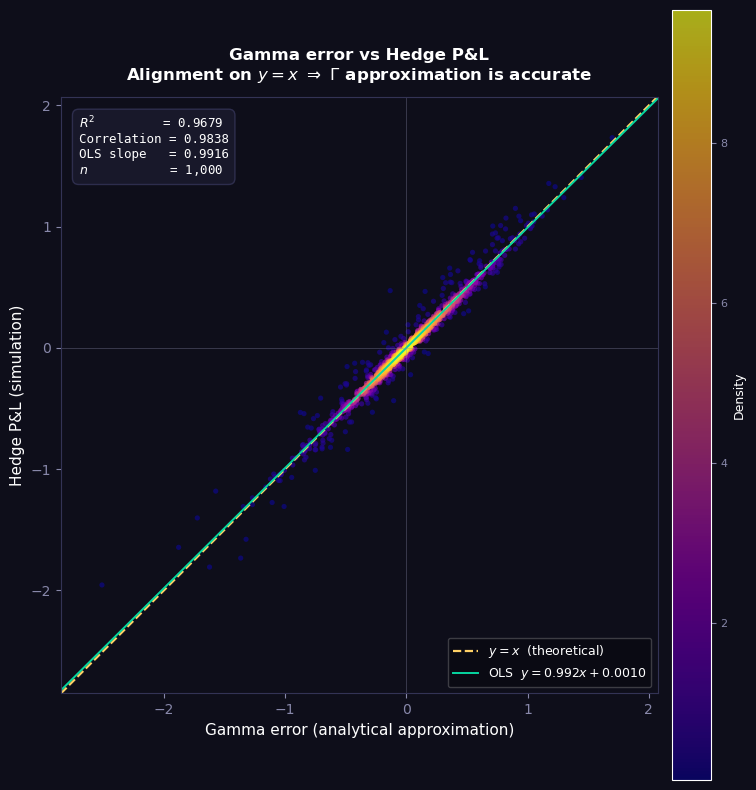

In [5]:
# Scatter plot: gamma error (x-axis) vs realised hedge P&L (y-axis)
# Points should align on the diagonal y = x if the gamma approximation is accurate
plot_gamma_vs_pnl(
    pnls_call,
    gamma_errors_call,
    figsize=(8, 8),
    style="dark_background",
)

**Reading the scatter plot:** Each point represents one simulated path. The dashed gold diagonal is the theoretical prediction $y = x$. The green line is the OLS fit with its $R^2$, correlation, and slope reported in the annotation box. Tight alignment on the diagonal confirms that the gamma approximation is an accurate predictor of the discrete hedging error. Deviations from the diagonal come from higher-order terms (cubic and above) in the Taylor expansion, which are non-negligible when the rebalancing interval is large or when the path realises extreme moves.

Figure saved: outputs/pnl_distribution.png


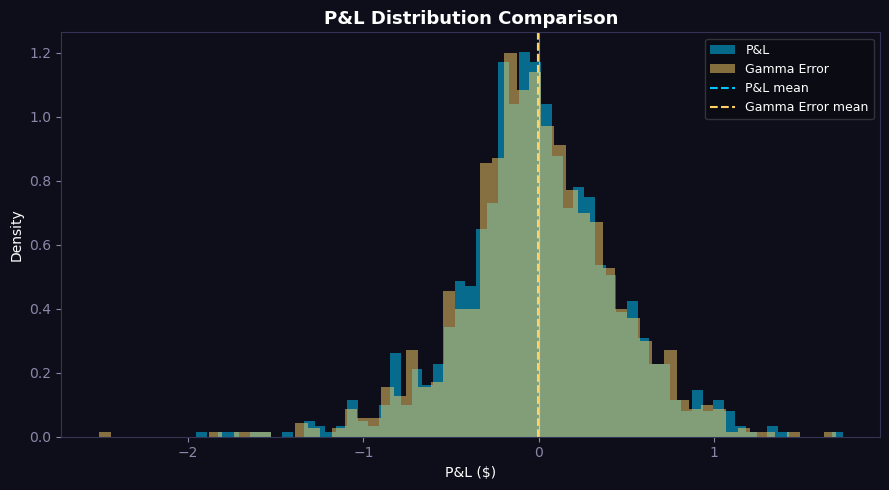

In [6]:
# Overlay the P&L and gamma error distributions
plot_pnl_distribution(pnls_call, gamma_errors_call)

**Reading the distribution plot:** The two histograms show the empirical densities of hedge P&L (blue) and gamma error (gold). Near-perfect overlap indicates the two quantities are almost identical across paths. Vertical dashed lines mark each distribution's mean. A narrow, symmetric distribution centred near zero is expected under daily rebalancing.

Figure saved: outputs/sample_paths.png


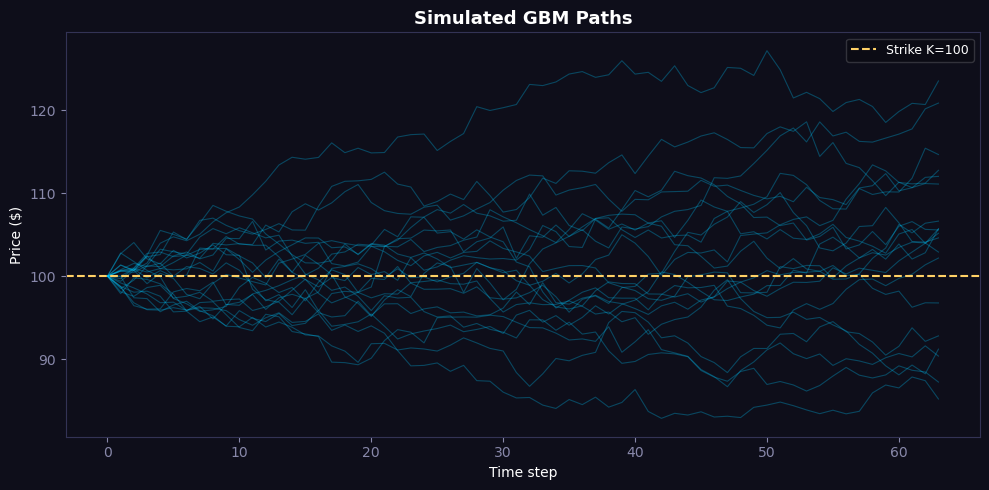

In [7]:
# Display a sample of simulated GBM paths
# The strike level is shown as a reference — paths crossing K affect option moneyness
plot_sample_paths(paths, K=PARAMS["K"])

---

## 6. Rebalancing Frequency Study

A core prediction of the BSM framework is that the quality of discrete replication deteriorates as the rebalancing frequency decreases. Specifically:

$$
\text{std}(\text{hedge error}) \propto \sqrt{\Delta t}
$$

This follows from the fact that the variance of the gamma error term $-\frac{1}{2}\Gamma[(\Delta S)^2 - \sigma^2 S^2 \Delta t]$ scales with $\Delta t^2$ per step, but summed over $T/\Delta t$ steps, the total variance scales with $\Delta t$.

We compare `rebal_freq ∈ {1, 3, 7, 10}` — i.e., rebalancing every 1, 3, 7, and 10 trading days.

In [8]:
pnls_dict  = {}   # rebal_freq -> array of P&L
gamma_dict = {}   # rebal_freq -> array of gamma errors

for freq in [1, 3, 7, 10]:
    pnls, gamma_errors, _ = run_backtest(**PARAMS, rebal_freq=freq, kind="call")
    pnls_dict[freq]  = pnls
    gamma_dict[freq] = gamma_errors
    print_stats(pnls, gamma_errors, f"Call | rebal_freq={freq} step(s)")


Results — Call | rebal_freq=1 step(s)
  Mean P&L              : -0.0044
  Mean gamma error      : -0.0054
  Std P&L               : 0.4472
  Std gamma error       : 0.4437
  P&L min / max         : -1.955 / 1.734
  VaR 95%               : -0.7622
  VaR 99%               : -1.2365
  CVaR 95%              : -1.0456
  Skewness              : -0.1786
  Kurtosis              : 1.4068
  |P&L| > 0.5  (%)      : 22.4%

Results — Call | rebal_freq=3 step(s)
  Mean P&L              : -0.0073
  Mean gamma error      : -0.0097
  Std P&L               : 0.7338
  Std gamma error       : 0.7377
  P&L min / max         : -2.880 / 2.724
  VaR 95%               : -1.2378
  VaR 99%               : -2.1468
  CVaR 95%              : -1.7870
  Skewness              : -0.2545
  Kurtosis              : 1.3238
  |P&L| > 0.5  (%)      : 41.0%

Results — Call | rebal_freq=7 step(s)
  Mean P&L              : -0.0291
  Mean gamma error      : -0.0341
  Std P&L               : 1.1052
  Std gamma error       : 1.06

Figure saved: outputs/rebal_comparison.png


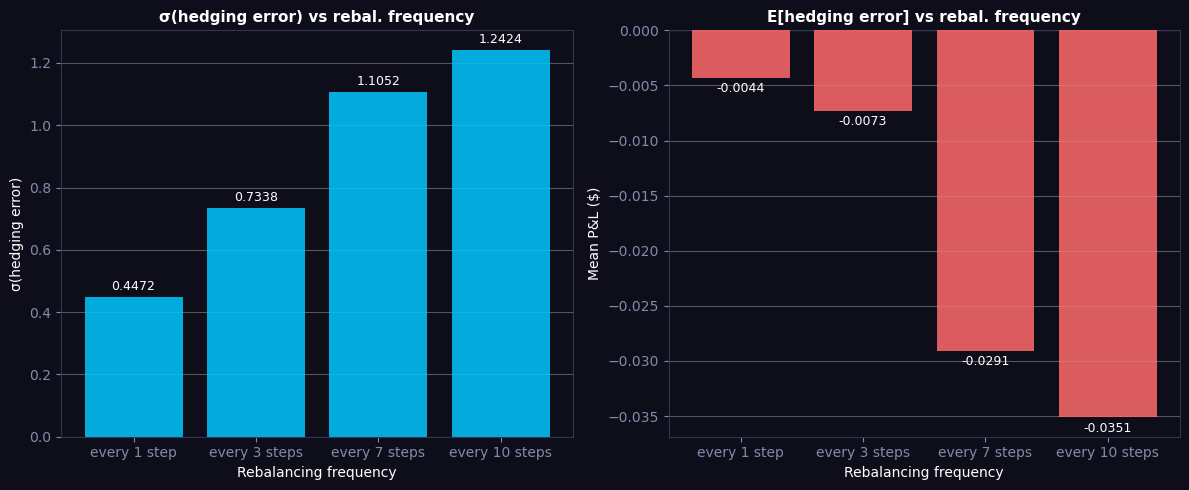

In [9]:
# Side-by-side bar charts: std and mean of hedging error vs rebalancing frequency
plot_rebal_comparison(pnls_dict)

**Reading the rebalancing comparison chart:**

- **Left panel — $\sigma$(hedging error):** the standard deviation grows with the rebalancing interval. This directly quantifies the additional residual risk borne by a hedger who cannot rebalance continuously.
- **Right panel — $\mathbb{E}[\text{hedging error}]$:** the mean hedging error should remain close to zero across all frequencies in the absence of transaction costs. Any non-trivial shift in the mean could indicate discretisation bias or path-dependent effects not captured by the linear approximation.

**Practical interpretation:** each additional day between rebalancings translates into a measurable increase in residual variance. A risk manager must therefore trade off the cost of frequent rebalancing (transaction costs, operational load) against the benefit of tighter P&L control.

---

## 7. Single-Path Hedge Trace

To build intuition about the mechanics of the strategy, we run a single path with the `full_trace=True` option, which records the complete time series of:
- the underlying price $S_t$,
- the theoretical (BSM) delta $\Delta_t^{\text{th}}$,
- the held delta $\Delta_t^{\text{held}}$ (step function, constant between rebalancings),
- the BSM option value $V_t$,
- the hedge portfolio value $\Pi_t$,
- the cumulative hedge P&L $\Pi_t - V_t$.

We use the same seed (42) so that the single path shown here is path 0 from the backtest.

In [10]:
PARAMS_TRACE = {
    "S0":         100,
    "K":          100,
    "T":          0.25,
    "r":          0.03,
    "q":          0.00,
    "sigma":      0.20,
    "n_steps":    63,
    "rebal_freq": 1,
    "trans_cost": 0.00,
    "seed":       42,
}

trace = run_trace(**PARAMS_TRACE, kind="call")

print(f"Terminal hedge P&L  : {trace['hedge_error']:+.6f}")
print(f"Gamma error approx. : {trace['gamma_error']:+.6f}")

Terminal hedge P&L  : +0.103453
Gamma error approx. : +0.126808


Figure saved: outputs/hedge_trace.png


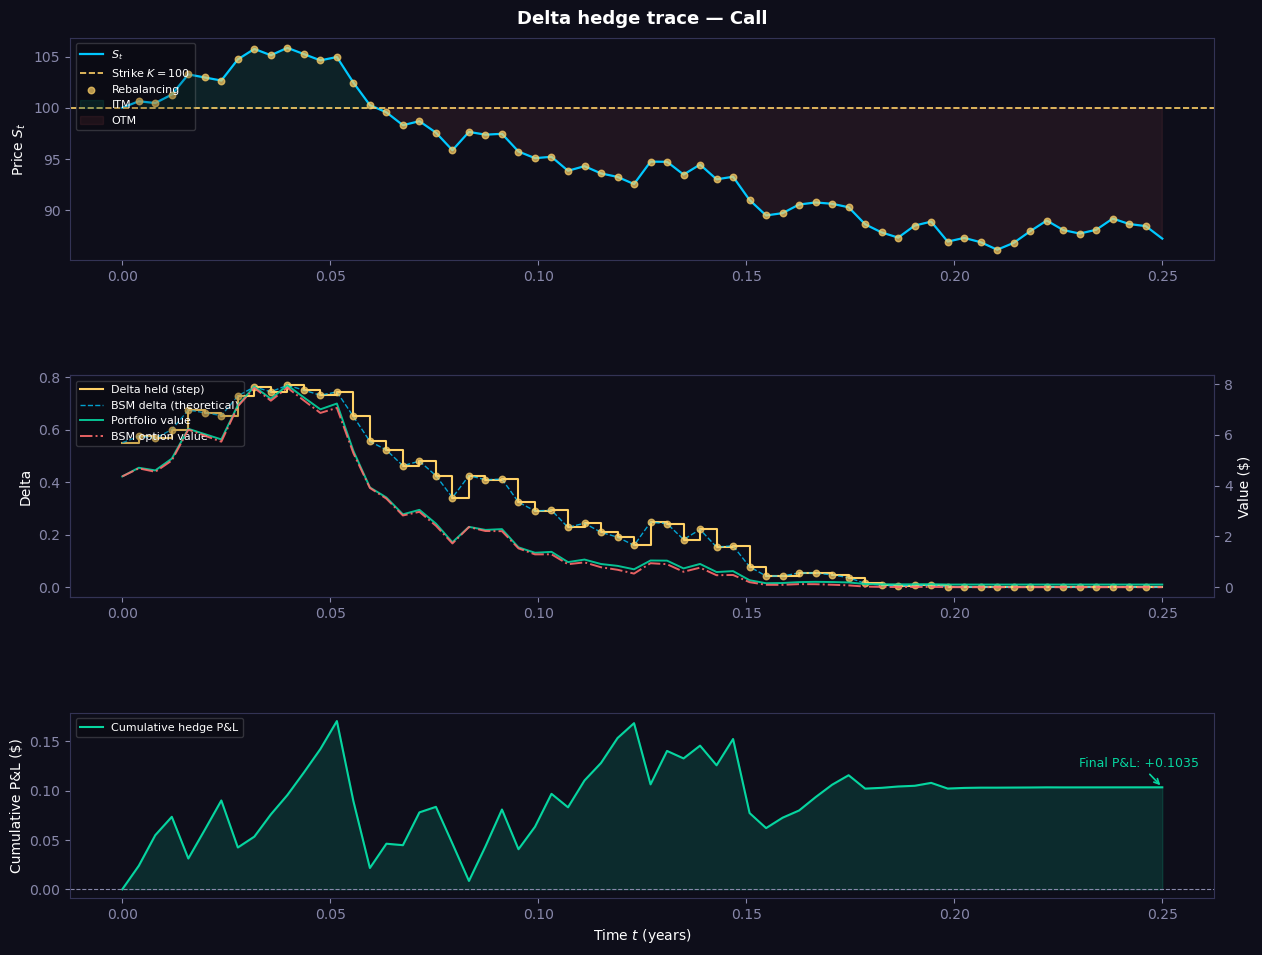

In [11]:
# Three-panel visualisation of the single-path hedge
plot_hedge_trace(trace, K=PARAMS_TRACE["K"])

**Reading the three-panel trace:**

- **Panel 1 — $S_t$ path:** the underlying price with the strike $K$ as a dashed line. Green-shaded regions indicate ITM periods for the call; red-shaded regions indicate OTM. Yellow dots mark each rebalancing event.

- **Panel 2 — Delta and option/portfolio values:** the theoretical BSM delta (dashed blue) is a smooth curve that rises toward 1 as the option goes deep in-the-money and falls toward 0 out-of-the-money. The held delta (gold step function) is updated only at rebalancing events. The right axis shows the portfolio value (green) tracking the BSM option value (red). Any gap between the two lines at a given time $t$ is the instantaneous hedging error — this gap should converge to the terminal P&L.

- **Panel 3 — Cumulative hedge P&L:** the difference $\Pi_t - V_t$ over time. Under perfect continuous hedging, this would be identically zero. Under discrete rebalancing, it fluctuates around zero with a characteristic sawtooth structure as the delta lags behind price movements. The final annotated value is the terminal hedging error.

The two quantities printed above — `hedge_error` and `gamma_error` — should be close in magnitude and sign for a well-behaved path.

---

## 8. Discussion

### 8.1 Why the Hedge Error Is Not Zero

Perfect replication requires continuous rebalancing. Under discrete rebalancing with step size $\Delta t > 0$, the hedge position is held constant between dates. During this interval, the option price moves non-linearly with $S_t$ (due to convexity, i.e., positive gamma), while the portfolio tracks $S_t$ only linearly. The curvature mismatch is the fundamental source of hedging error.

### 8.2 Why Gamma Error ≈ Hedge P&L

The gamma error formula captures the leading-order discretisation term. When $\Delta t$ is small (daily rebalancing), higher-order terms are negligible, so the gamma error is an accurate approximation of the realised P&L. A high $R^2$ and OLS slope close to 1 in the scatter plot is empirical confirmation of this.

### 8.3 Sources of Deviation Between Gamma Error and P&L

Deviations between the two quantities arise from:
- **Higher-order terms:** the third-order (speed, $\partial^3 V / \partial S^3$) and cross terms become non-negligible when $\Delta t$ is large or when the path realises extreme moves.
- **Floating-point discretisation:** the GBM step uses the Euler-Maruyama discretisation for the log price, which introduces a small second-order bias.
- **Gamma interpolation:** the gamma error uses the gamma evaluated at the *start* of each rebalancing interval. Over longer intervals, the gamma changes materially, introducing approximation error.

### 8.4 Impact of Rebalancing Frequency

Reducing the rebalancing frequency increases the variance of the hedging error approximately proportionally to $\sqrt{\Delta t}$. This is consistent with the well-known result that the standard deviation of the total gamma P&L over a path scales as $\sigma^2 \sqrt{T / n}$ for $n$ rebalancing steps. The mean error remains near zero in the absence of transaction costs.

### 8.5 Role of Transaction Costs

In the current baseline, transaction costs are set to zero. In practice, each rebalancing incurs a proportional cost `trans_cost * |Δdelta| * S`. This creates a direct tension: more frequent rebalancing reduces variance but increases transaction costs. Leland (1985) showed that, under proportional transaction costs, one can adjust the implied volatility used in the BSM formula to approximately offset the transaction cost drain.

### 8.6 Model Limitations

The BSM model makes several assumptions that are violated in practice:
- Constant volatility (no volatility smile or term structure).
- Continuous trading with no market impact.
- Log-normal returns with no jumps.
- Constant risk-free rate and dividend yield.

In particular, if realised volatility differs from the implied volatility used to compute delta, the hedge will carry a systematic vega exposure that is not captured by the gamma error formula.

---

## 9. Limitations and Possible Extensions

This project provides a clean, self-contained implementation of BSM delta hedging. Several natural extensions would increase realism and analytical depth:

### 9.1 Stochastic Volatility
Under Heston or SABR dynamics, volatility itself is random. Delta hedging under a misspecified constant-vol model incurs a residual vega risk. One could extend the simulator to generate paths under stochastic volatility while pricing and hedging with BSM, quantifying the **model risk** embedded in the hedging error.

### 9.2 Jump Processes
Merton's jump-diffusion model adds Poisson jumps to the GBM. Delta hedging does not protect against jump risk; the hedge error distribution would develop heavier tails and potentially larger skewness.

### 9.3 Transaction Costs and Optimal Rebalancing
The Leland (1985) adjustment modifies the effective volatility used in BSM to absorb transaction costs:
$$
\hat{\sigma}^2 = \sigma^2\left(1 + \kappa\sqrt{\frac{2}{\pi}} \cdot \frac{1}{\sigma\sqrt{\Delta t}}\right)
$$
where $\kappa$ is the round-trip transaction cost rate. More sophisticated approaches (Zakamouline, Whalley-Wilmott) derive utility-based optimal hedging bands.

### 9.4 Volatility Mis-specification
Hedging with an incorrect $\sigma$ (e.g., historical vs. implied) introduces a systematic P&L drift proportional to $(\sigma_{\text{realised}}^2 - \sigma_{\text{implied}}^2)$ scaled by vega. This can be analysed by running the backtest with GBM paths generated under a different volatility than the one used for pricing.

### 9.5 Alternative Hedging Rules
Instead of time-based rebalancing, one could implement:
- **Delta-band triggers:** rebalance only when $|\Delta_{\text{held}} - \Delta_{\text{th}}| > \epsilon$.
- **Gamma-weighted scheduling:** rebalance more frequently when gamma is high (near ATM, near expiry).
- **Minimum variance hedging:** extend the hedge to include vega by trading in options.

---

## 10. Conclusion

This project demonstrates that discrete delta hedging under the BSM model produces a residual hedge P&L that is well-explained by the gamma-based second-order approximation. Under daily rebalancing with at-the-money parameters, the gamma error accounts for the vast majority of the hedging error variance, with $R^2$ close to 1 and OLS slope close to 1.

The rebalancing frequency study confirms the theoretical prediction: reducing the frequency of hedge updates monotonically inflates the standard deviation of the residual risk while leaving the mean error near zero in the absence of transaction costs. This quantifies the practical replication-cost trade-off every derivatives desk must navigate.

The single-path trace provides an intuitive view of how the step-function delta held by the hedger diverges from the smooth theoretical delta, and how this divergence compounds into the terminal P&L. The three-panel visualisation makes the mechanics of the strategy transparent.

The codebase is modular, numerically consistent with the BSM analytical formulas, and structured to support straightforward extension to stochastic volatility, transaction cost models, and alternative hedging rules.